<a href="https://colab.research.google.com/github/Shivtej5151/DATAscience-experiments/blob/main/skillLCA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#%% Dataset Merging & Initial Preprocessing
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt
import seaborn as sns

files = [
    '/content/reduced_data_1.csv',
    '/content/reduced_data_2.csv',
    '/content/reduced_data_3.csv',
    '/content/reduced_data_4.csv'
]

df_list = [pd.read_csv(f) for f in files]
df = pd.concat(df_list, ignore_index=True)
df

<ipython-input-1-3c0e3f367db9>:18: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in files]
<ipython-input-1-3c0e3f367db9>:18: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in files]
<ipython-input-1-3c0e3f367db9>:18: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in files]
<ipython-input-1-3c0e3f367db9>:18: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f) for f in files]


,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory
0,1,1.528089e+09,e,1,tcp,1,192.168.100.147,49960,192.168.100.7,80,...,1.127040,96,75,1.133720,1.129970,770,602,1,DoS,HTTP
1,2,1.528089e+09,e,1,arp,2,192.168.100.7,-1,192.168.100.147,-1,...,15267.200000,1,2,0.005142,0.005142,2,6,1,DoS,HTTP
2,3,1.528089e+09,e,1,tcp,1,192.168.100.147,49962,192.168.100.7,80,...,1.127040,96,75,1.135100,1.129970,770,602,1,DoS,HTTP
3,4,1.528089e+09,e,1,tcp,1,192.168.100.147,49964,192.168.100.7,80,...,1.127040,96,75,1.135140,1.129970,770,602,1,DoS,HTTP
4,5,1.528089e+09,e,1,tcp,1,192.168.100.147,49966,192.168.100.7,80,...,1.127040,96,75,1.135260,1.129970,770,602,1,DoS,HTTP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3668517,3668518,1.529381e+09,e,1,tcp,1,192.168.100.150,35064,192.168.100.3,22,...,9.889330,19,19,455.754000,9.889330,30,30,1,Theft,Keylogging
3668518,3668519,1.529381e+09,e,1,tcp,1,192.168.100.150,35066,192.168.100.3,22,...,9.889330,19,19,10453.000000,9.889330,30,30,1,Theft,Keylogging
3668519,3668520,1.529381e+09,e,1,tcp,1,192.168.100.150,35070,192.168.100.3,22,...,9.889330,19,19,10.785200,9.889330,441,441,1,Theft,Keylogging
3668520,3668521,1.529381e+09,e,1,tcp,1,192.168.100.3,43001,192.168.100.150,4433,...,666667.000000,1,3,666667.000000,22346.400000,2,4,1,Theft,Keylogging


In [ ]:
# Data Cleaning & Encoding

df.dropna(inplace=True)

label_encoder = LabelEncoder()
df['proto'] = label_encoder.fit_transform(df['proto'])
df['state'] = label_encoder.fit_transform(df['state'])
df['attack'] = label_encoder.fit_transform(df['attack'])  # Target encoding
df['category'] = label_encoder.fit_transform(df['category'])
df['subcategory'] = label_encoder.fit_transform(df['subcategory'])
df['flgs'] = label_encoder.fit_transform(df['flgs'])


df = df.drop(['saddr', 'sport', 'daddr', 'dport', 'seq', 'stime', 'ltime'], axis=1,errors='ignore')

scaler = StandardScaler()

existing_cols = df.columns.intersection([
    'dur', 'sbytes', 'dbytes', 'spkts', 'dpkts',
    'smeansz', 'dmeansz', 'trans', 'appname'
])

df[existing_cols] = scaler.fit_transform(df[existing_cols])
df


,pkSeqID,flgs,flgs_number,proto,proto_number,pkts,bytes,state,state_number,dur,...,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory
0,1,0,1,3,1,8,1980,8,1,-0.617955,...,1.127040,96,75,1.133720,1.129970,770,602,1,1,1
1,2,0,1,0,2,2,120,1,2,-0.946342,...,15267.200000,1,2,0.005142,0.005142,2,6,1,1,1
2,3,0,1,3,1,8,2126,8,1,-0.618353,...,1.127040,96,75,1.135100,1.129970,770,602,1,1,1
3,4,0,1,3,1,8,2024,8,1,-0.618365,...,1.127040,96,75,1.135140,1.129970,770,602,1,1,1
4,5,0,1,3,1,8,2319,8,1,-0.618400,...,1.127040,96,75,1.135260,1.129970,770,602,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3668517,3668518,0,1,3,1,6,434,8,1,-0.945736,...,9.889330,19,19,455.754000,9.889330,30,30,1,4,2
3668518,3668519,0,1,3,1,6,434,8,1,-0.946322,...,9.889330,19,19,10453.000000,9.889330,30,30,1,4,2
3668519,3668520,0,1,3,1,31,5472,3,6,-0.812583,...,9.889330,19,19,10.785200,9.889330,441,441,1,4,2
3668520,3668521,0,1,3,1,2,134,8,1,-0.946348,...,666667.000000,1,3,666667.000000,22346.400000,2,4,1,4,2


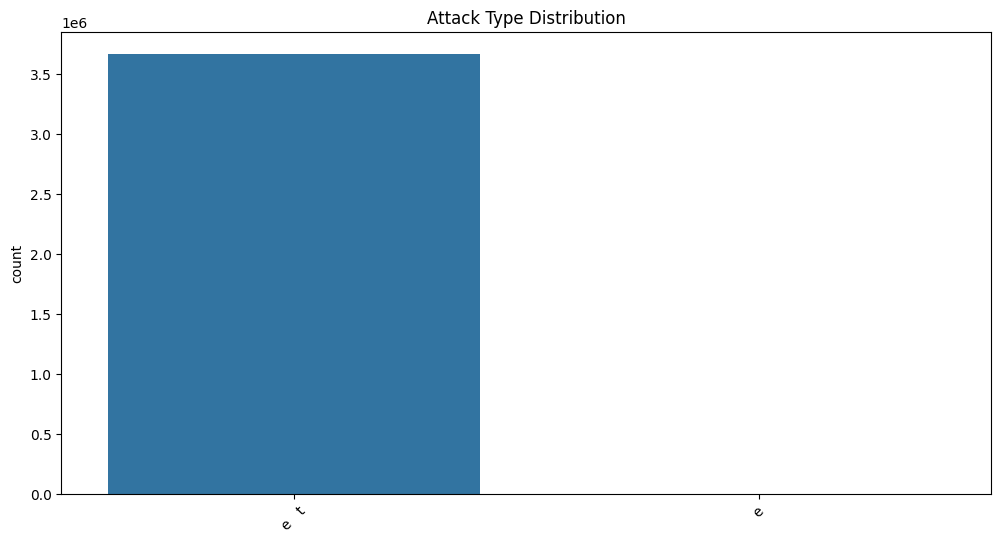

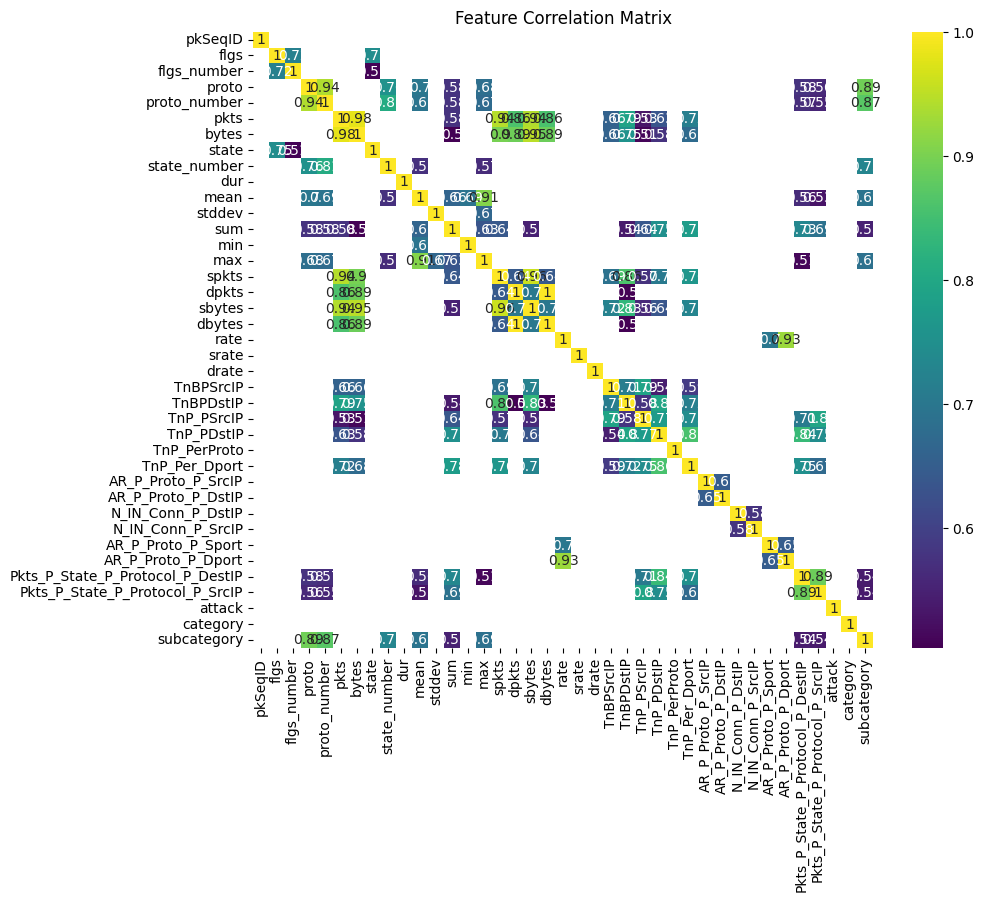

In [ ]:
#%% Visualization
plt.figure(figsize=(12,6))
sns.countplot(x=label_encoder.inverse_transform(df['attack']))
plt.title('Attack Type Distribution')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix[corr_matrix > 0.5], annot=True, cmap='viridis')
plt.title('Feature Correlation Matrix')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected Features: ['pkSeqID', 'dur', 'sum', 'rate', 'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP', 'N_IN_Conn_P_DstIP', 'AR_P_Proto_P_Sport', 'AR_P_Proto_P_Dport']


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    577987
           1       1.00      0.95      0.97    495078
           2       0.00      0.00      0.00       143
           3       0.89      0.96      0.92     27325
           4       0.00      0.00      0.00        24

    accuracy                           0.97   1100557
   macro avg       0.57      0.58      0.57   1100557
weighted avg       0.97      0.97      0.97   1100557


Decision Tree Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    577987
           1       1.00      1.00      1.00    495078
           2       1.00      0.99      1.00       143
           3       1.00      1.00      1.00     27325
           4       1.00      0.96      0.98        24

    accuracy                           1.00   1100557
   macro avg       1.00      0.99      1.00   1100557
weighted avg   

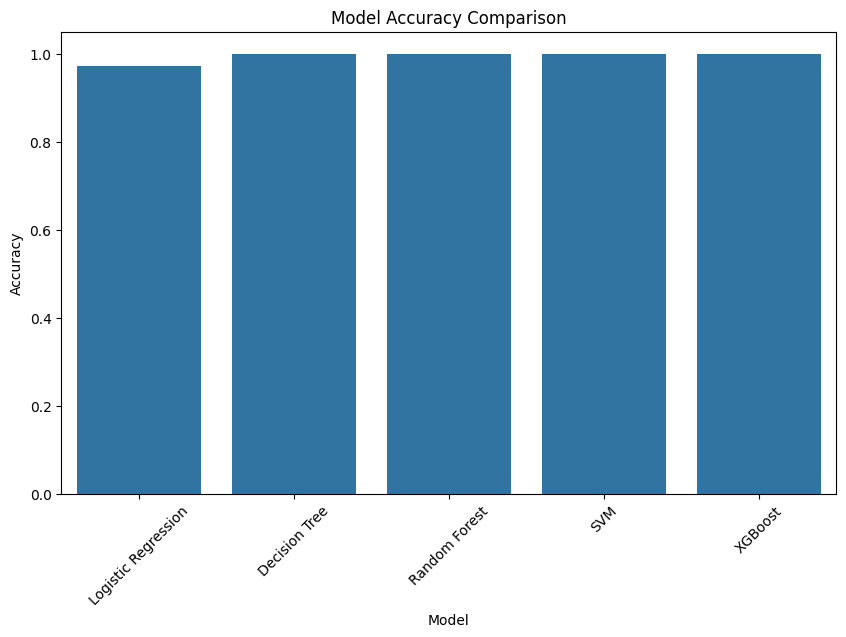

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


# Feature Selection (Embedded Method)
X = df.drop('category', axis=1)
y = df['category']

# Train Random Forest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Select top 15 features
selector = SelectFromModel(rf, prefit=True, max_features=15)
X_selected = selector.transform(X)

# Get selected feature names
selected_features = X.columns[selector.get_support()]
print("Selected Features:", list(selected_features))

# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(kernel='linear'),
    "XGBoost": XGBClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = classification_report(y_test, y_pred, output_dict=True)
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [v['accuracy'] for v in results.values()],
    'F1-Score': [v['weighted avg']['f1-score'] for v in results.values()]
})

plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
target_col = 'Pkts_P_State_P_Protocol_P_SrcIP'
X = df.drop(target_col, axis=1)
y = df[target_col]
# Train Random Forest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Select top 15 features
selector = SelectFromModel(rf, prefit=True, max_features=15)
X_selected = selector.transform(X)

# Get selected feature names
selected_features = X.columns[selector.get_support()]
print("Selected Features:", list(selected_features))

#%% Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42, stratify=y)

#%% Model Training & Evaluation
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(kernel='linear'),
    "XGBoost": XGBClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = classification_report(y_test, y_pred, output_dict=True)
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))

#%% Results Comparison
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [v['accuracy'] for v in results.values()],
    'F1-Score': [v['weighted avg']['f1-score'] for v in results.values()]
})

plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.show()